# SentinelMail — BERT Fine-Tuned: Training & Evaluation

Fine-tunes `bert-base-uncased` on the ai4privacy training split and evaluates it on the
validation split. Saves metrics to `evaluation/results/bert_metrics.json` for ensemble comparison.

**Prerequisites**
- `pip install transformers torch`
- HuggingFace model weights downloaded automatically on first run

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from tqdm.auto import tqdm

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

CHECKPOINT_DIR = REPO_ROOT / "models" / "bert" / "checkpoint"
RESULTS_DIR    = REPO_ROOT / "evaluation" / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

/Users/erelv/projects-chkp/final-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps


In [2]:
from data.preprocessing import load_split, LABEL_COLS
from models.bert.dataset import DLPDataset, collate_fn
from models.bert.model   import BertForDLPClassification
from models.bert.predict import BertDLPDetector
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
    from_dataframe,
    LABEL_COLS,
)

## 1. Load Data

In [5]:
print("Loading splits...")
train_df = load_split("train")
val_df   = load_split("validation")

train_texts  = train_df["source_text"].tolist()
val_texts    = val_df["source_text"].tolist()
train_labels = train_df[LABEL_COLS].values.astype(np.float32)
val_labels   = val_df[LABEL_COLS].values.astype(np.float32)

print(f"Train: {len(train_texts):,} samples")
print(f"Val:   {len(val_texts):,} samples")
print()
print("Label distribution (train):")
print(train_df[LABEL_COLS].sum().to_string())

Loading splits...
Train: 29,908 samples
Val:   7,946 samples

Label distribution (train):
benign           3482
PII             26426
financial        5688
confidential    13252


## 2. Encode Inputs

In [4]:
MODEL_NAME = "bert-base-uncased"
BATCH_SIZE = 16

print(f"Loading {MODEL_NAME} encoder...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = DLPDataset(train_texts, train_labels, tokenizer)
val_ds   = DLPDataset(val_texts,   val_labels,   tokenizer)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Loading bert-base-uncased encoder...
Train batches: 1,870  |  Val batches: 497


## 3. Initialise Model

In [5]:
model = BertForDLPClassification().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}  (blocks 10-11 + head)")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7997.49it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params:     109,485,316
Trainable params: 14,769,412  (blocks 10-11 + head)


## 4. Train

Skip this cell if `checkpoint/best_model.pt` already exists — section 5 loads it.

Early stopping on **val macro-F1** (not val loss) as per ADR-001.

In [6]:
EPOCHS           = 5
LR               = 2e-5
LABEL_SMOOTHING  = 0.05
WARMUP_FRACTION  = 0.10
CKPT             = CHECKPOINT_DIR / "best_model.pt"


def _pos_weights(labels: np.ndarray, device: torch.device) -> torch.Tensor:
    pos = labels.sum(axis=0).clip(1)
    neg = len(labels) - pos
    return torch.tensor(neg / pos, dtype=torch.float32).to(device)


def _smooth(labels: torch.Tensor, eps: float = LABEL_SMOOTHING) -> torch.Tensor:
    return labels * (1.0 - eps) + (1.0 - labels) * eps


def _macro_f1_from_logits(logits_list, labels_list) -> float:
    proba  = torch.sigmoid(torch.cat(logits_list)).cpu().numpy()
    y_pred = (proba >= 0.5).astype(int)
    y_true = torch.cat(labels_list).cpu().numpy().astype(int)
    f1s = []
    for i in range(4):
        tp = ((y_pred[:, i] == 1) & (y_true[:, i] == 1)).sum()
        fp = ((y_pred[:, i] == 1) & (y_true[:, i] == 0)).sum()
        fn = ((y_pred[:, i] == 0) & (y_true[:, i] == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1s.append(2 * p * r / (p + r) if (p + r) > 0 else 0.0)
    return float(np.mean(f1s))


criterion = nn.BCEWithLogitsLoss(pos_weight=_pos_weights(train_labels, DEVICE))
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=0.01
)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(WARMUP_FRACTION * total_steps)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for input_ids, attention_mask, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        input_ids, attention_mask, labels = (
            input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
        )
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, _smooth(labels))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    val_logits_all, val_labels_all = [], []
    with torch.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids, attention_mask, labels_dev = (
                input_ids.to(DEVICE), attention_mask.to(DEVICE), labels.to(DEVICE)
            )
            logits    = model(input_ids, attention_mask)
            val_loss += criterion(logits, _smooth(labels_dev)).item()
            val_logits_all.append(logits.detach())
            val_labels_all.append(labels)

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    val_f1    = _macro_f1_from_logits(val_logits_all, val_labels_all)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["val_f1"].append(val_f1)

    marker = "  ✓ saved" if val_f1 > best_val_f1 else ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT)
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}  macro-F1={val_f1:.4f}{marker}")

print(f"\nBest val macro-F1: {best_val_f1:.4f}  →  {CKPT}")

Epoch 01 train:   0%|          | 0/1870 [00:00<?, ?it/s]

Epoch 01/5  train=0.5910  val=0.4760  macro-F1=0.9182  ✓ saved


Epoch 02/5  train=0.4651  val=0.4587  macro-F1=0.9232  ✓ saved


Epoch 03/5  train=0.4489  val=0.4503  macro-F1=0.9459  ✓ saved


Epoch 04/5  train=0.4388  val=0.4487  macro-F1=0.9459


Epoch 05/5  train=0.4333  val=0.4476  macro-F1=0.9492  ✓ saved

Best val macro-F1: 0.9492  →  /Users/erelv/projects-chkp/final-project/models/bert/checkpoint/best_model.pt


### 4a. Learning Curves

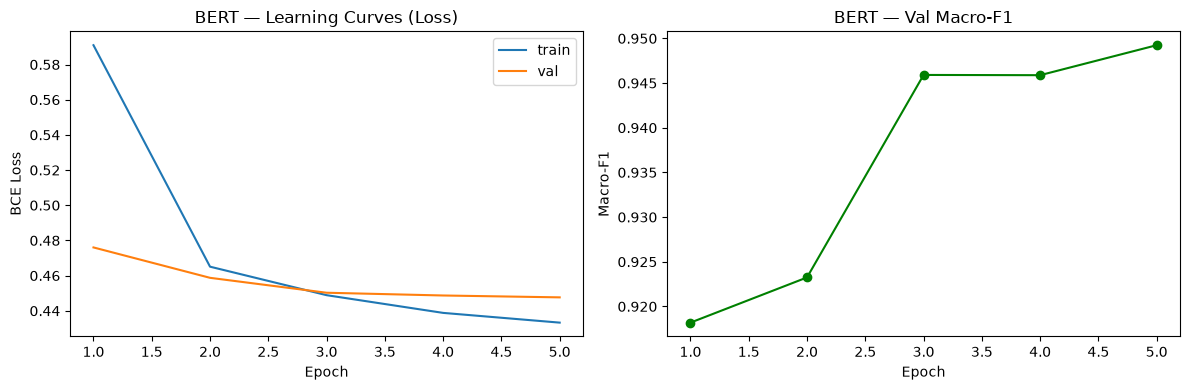

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("BERT — Learning Curves (Loss)")
axes[0].legend()

axes[1].plot(epochs_range, history["val_f1"], color="green", marker="o")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro-F1")
axes[1].set_title("BERT — Val Macro-F1")

plt.tight_layout()
plt.show()

## 5. Load Best Checkpoint

In [3]:
CKPT = CHECKPOINT_DIR / "best_model.pt"

detector = BertDLPDetector(
    checkpoint_path=str(CKPT),
    device=str(DEVICE),
)
print(f"Loaded: {CKPT.name}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6666.61it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded: best_model.pt


## 6. Run Inference on Validation Set

In [6]:
THRESHOLD = 0.5

print(f"Running predict_proba on {len(val_texts):,} samples...")
y_proba = detector.predict_proba(val_texts)       # (N, 4) float32
y_pred  = (y_proba >= THRESHOLD).astype(np.int32) # (N, 4) int
y_true  = from_dataframe(val_df)                   # (N, 4) int

print(f"y_proba range: [{y_proba.min():.3f}, {y_proba.max():.3f}]")
print()
print(f"{'label':14s}  {'pred':>6s}  {'true':>6s}")
for i, col in enumerate(LABEL_COLS):
    print(f"  {col:12s}  {y_pred[:,i].sum():6d}  {y_true[:,i].sum():6d}")

Running predict_proba on 7,946 samples...
y_proba range: [0.003, 0.998]

label             pred    true
  benign          1011     908
  PII             6944    7038
  financial       1579    1529
  confidential    3707    3632


## 7. Metrics

In [7]:
metrics = compute_all_metrics(y_true, y_pred, y_proba=y_proba)

ci = metrics["macro_f1_ci"]
print(f"Macro-F1:      {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}])")
print(f"Macro AUC-ROC: {metrics['auc_roc']['macro']:.4f}")
print()

pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1:      0.9624  (95% CI: [0.9588, 0.9660])
Macro AUC-ROC: 0.9908



,precision,recall,f1,support
benign,0.8635,0.9615,0.9098,908.0
PII,0.9948,0.9815,0.9881,7038.0
financial,0.9120,0.9418,0.9266,1529.0
confidential,0.9625,0.9824,0.9723,3632.0


### 7a. Threshold Sensitivity (0.3 / 0.5 / 0.7)

In [8]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m   = compute_all_metrics(y_true, (y_proba >= t).astype(np.int32), n_bootstrap=50)
    row = {"threshold": t, "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

pd.DataFrame(rows).set_index("threshold")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
threshold,,,,,
0.3,0.9442,0.6088,0.9912,0.8750,0.9665
0.5,0.9624,0.9098,0.9881,0.9266,0.9723
0.7,0.9390,0.9335,0.9044,0.9401,0.9726


## 8. Confusion Matrices & Per-Label Bars

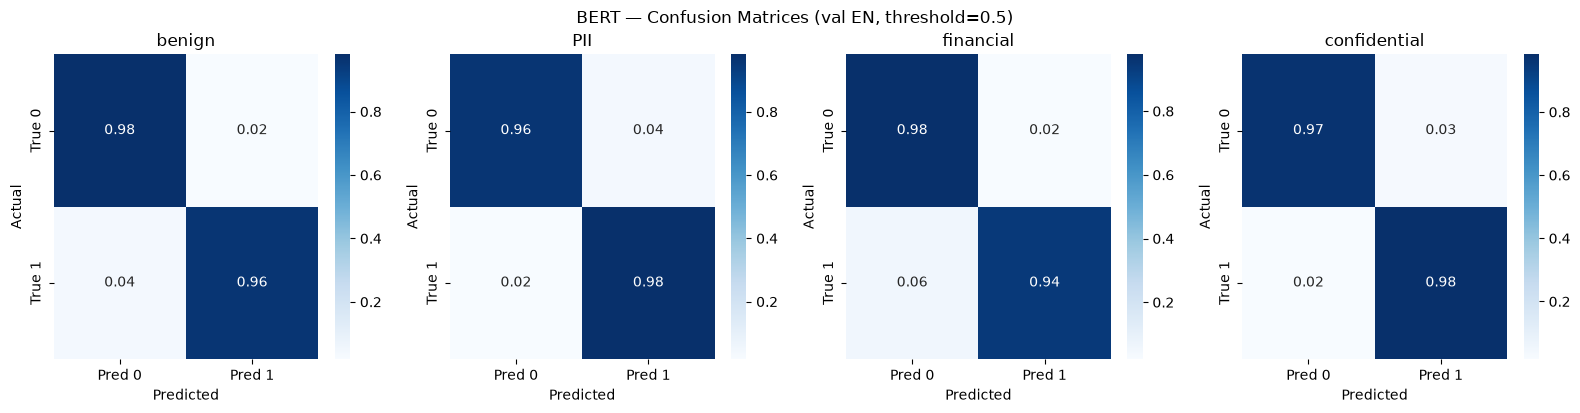

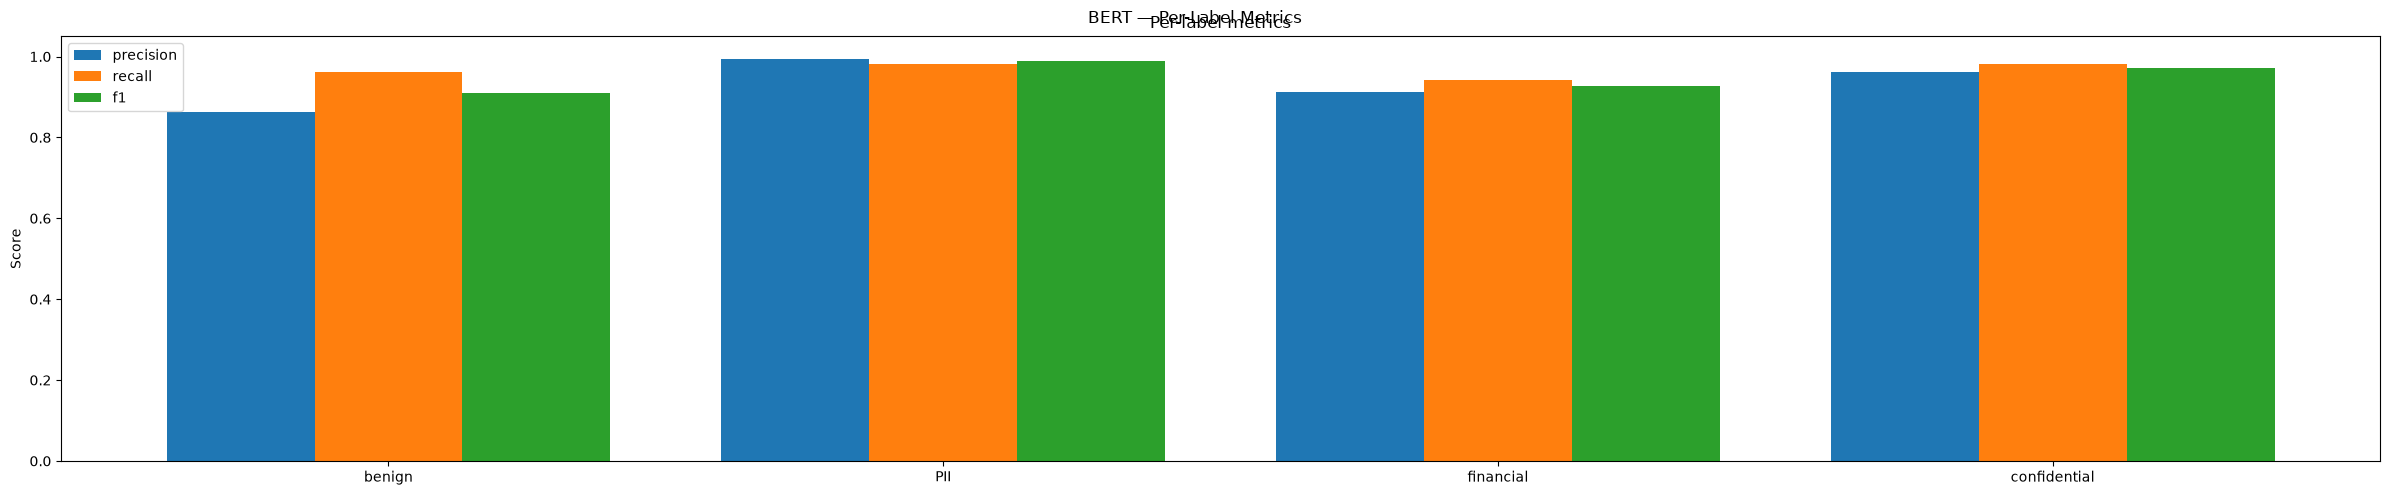

In [9]:
_, fig = plot_confusion_matrices(y_true, y_pred, normalize="true", return_fig=True)
fig.suptitle("BERT — Confusion Matrices (val EN, threshold=0.5)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
bar_fig.suptitle("BERT — Per-Label Metrics")
plt.show()

## 9. ROC & PR Curves

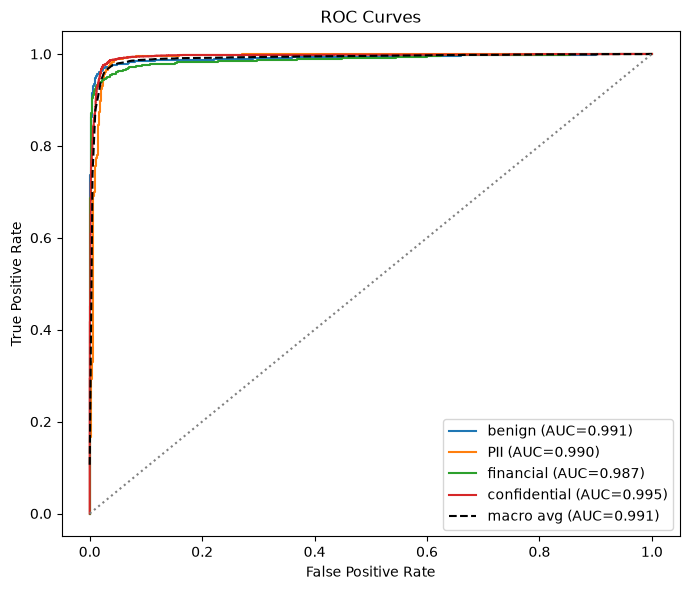

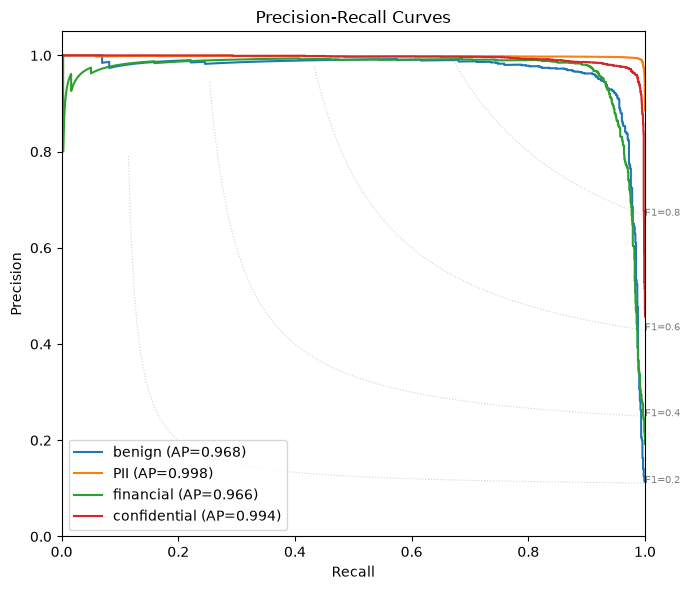

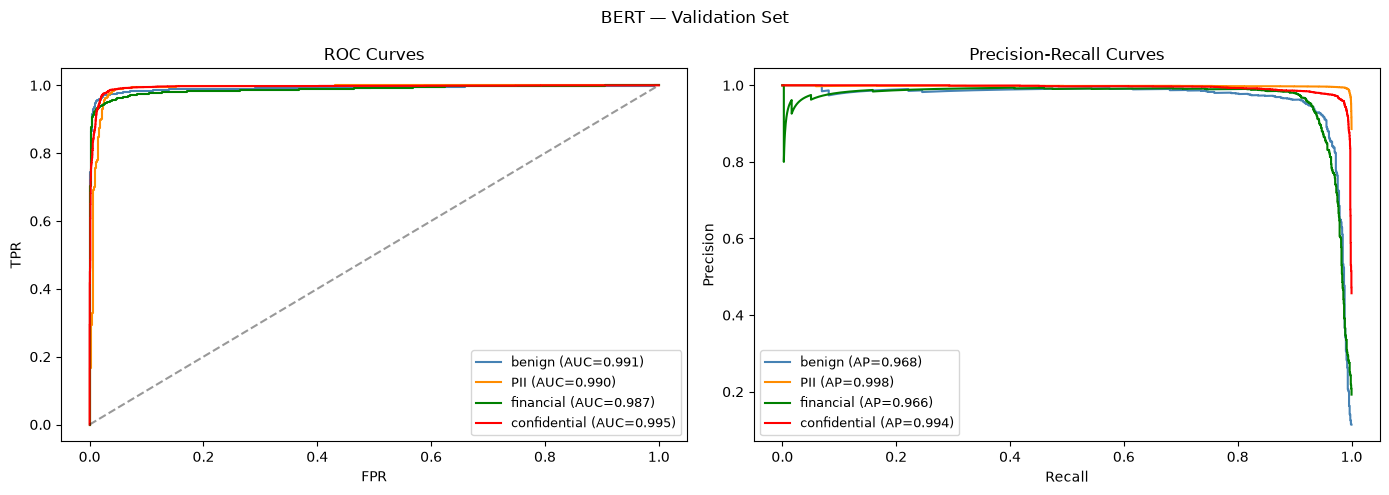

In [10]:
roc_data = plot_roc_curves(y_true, y_proba)
pr_data  = plot_pr_curves(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["steelblue", "darkorange", "green", "red"]

for i, label in enumerate(LABEL_COLS):
    axes[0].plot(roc_data[label]["fpr"], roc_data[label]["tpr"],
                 label=f"{label} (AUC={roc_data[label]['auc']:.3f})", color=COLORS[i])
    axes[1].plot(pr_data[label]["recall"], pr_data[label]["precision"],
                 label=f"{label} (AP={pr_data[label]['ap']:.3f})", color=COLORS[i])

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9)
fig.suptitle("BERT — Validation Set")
plt.tight_layout()
plt.show()

## 10. Error Analysis

Classifies FP/FN into the four taxonomy buckets (descriptive error analysis for RQ1/RQ2 model comparison).

In [11]:
texts = val_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,0,1,4,3
FN_obfuscated,0,0,9,2
FP_hypothetical,1,3,2,2
FP_negation,4,15,9,9
other_FN,20,20,20,20
other_FP,20,20,20,20


In [12]:
def show_bucket(key: str, n: int = 5) -> None:
    records = error_results.get(key, [])
    print(f"\n{'─'*60}")
    print(f"{key}  ({len(records)} total, showing {min(n, len(records))})")
    print(f"{'─'*60}")
    for r in records[:n]:
        print(f"  [{r['label']}] {r['text_snippet'][:120].replace(chr(10), ' ')}")

show_bucket("FP_negation")
show_bucket("FP_hypothetical")
show_bucket("FN_obfuscated")
show_bucket("FN_implicit")


────────────────────────────────────────────────────────────
FP_negation  (37 total, showing 5)
────────────────────────────────────────────────────────────
  [financial] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [confidential] 17\tAssessment Feedback Report\tReport providing students with feedback on their performance in assessments. Feminine\Ja
  [confidential] sponsible for all activities conducted under their accounts. 2. Users must maintain the confidentiality of their login c
  [financial] al battlefield. Engage in battles of wits and strategy as you navigate through challenging levels and quests.  Compete w
  [confidential] History* - **Surgery**: true   - **Allergies**: None    *Family Medical Background* - **Mother's Health**: M_HEALTH_A(Go

────────────────────────────────────────────────────────────
FP_hypothetical  (8 total, showing 5)
──────────────────────────────────────────────────────────

## 11. Save Results

In [16]:
out_path = RESULTS_DIR / "bert_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="bert_finetuned",
    n_samples=len(val_df),
    threshold=THRESHOLD,
    extra_metadata={
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "base_model": MODEL_NAME,
        "frozen_blocks": "0-9",
        "label_smoothing": LABEL_SMOOTHING,
        "checkpoint": str(CKPT),
    },
)

print(f"Saved to {out_path}")

Saved to /Users/erelv/projects-chkp/final-project/evaluation/results/bert_metrics.json


## 12. Cross-Validation Robustness (5-fold on train split)

CV was run on the ai4privacy **train** split; the held-out **validation** (test) split
was never touched. Results show mean ± std across 5 folds, confirming that the
single-run test metrics are not a lucky split.

In [13]:
import json

kfold_path = RESULTS_DIR / "kfold_cv_bert.json"
with open(kfold_path) as f:
    kfold = json.load(f)

agg = kfold["aggregated"]

rows = []
for label in LABEL_COLS:
    cv_mean = agg["per_label"][label]["f1_mean"]
    cv_std  = agg["per_label"][label]["f1_std"]
    test_f1 = metrics["per_label"][label]["f1"]
    rows.append({
        "label":           label,
        "CV mean F1":      round(cv_mean, 4),
        "CV std":          round(cv_std,  4),
        "Test F1":         round(test_f1, 4),
        "delta (test-CV)": round(test_f1 - cv_mean, 4),
    })

rows.append({
    "label":           "MACRO",
    "CV mean F1":      round(agg["macro_f1_mean"], 4),
    "CV std":          round(agg["macro_f1_std"],  4),
    "Test F1":         round(metrics["macro_f1"],  4),
    "delta (test-CV)": round(metrics["macro_f1"] - agg["macro_f1_mean"], 4),
})

cv_df = pd.DataFrame(rows).set_index("label")
print(f"CV config: {agg["configuration"]}  |  k={kfold["k"]}  |  seed={kfold["seed"]}")
display(cv_df)

CV config: solo_bert  |  k=5  |  seed=42


,CV mean F1,CV std,Test F1,delta (test-CV)
label,,,,
benign,0.8952,0.0082,0.9098,0.0147
PII,0.9838,0.0017,0.9881,0.0043
financial,0.9263,0.0060,0.9266,0.0003
confidential,0.9659,0.0035,0.9723,0.0065
MACRO,0.9587,0.0027,0.9624,0.0037


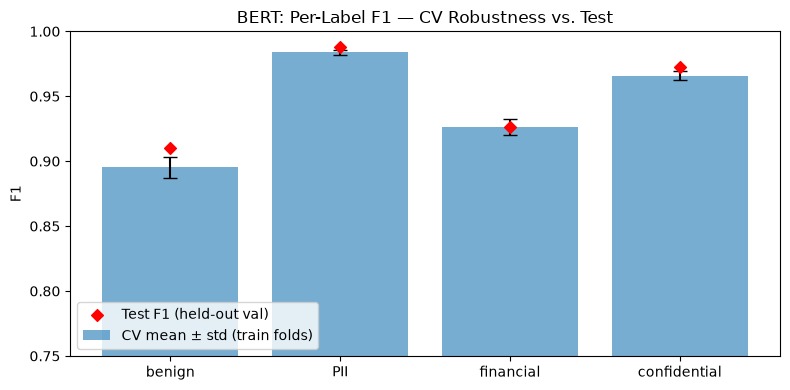

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(LABEL_COLS))
cv_means = [agg["per_label"][l]["f1_mean"] for l in LABEL_COLS]
cv_stds  = [agg["per_label"][l]["f1_std"]  for l in LABEL_COLS]
test_f1s = [metrics["per_label"][l]["f1"] for l in LABEL_COLS]

ax.bar(x, cv_means, yerr=cv_stds, capsize=5, alpha=0.6, label="CV mean ± std (train folds)")
ax.scatter(x, test_f1s, marker="D", color="red", zorder=5, label="Test F1 (held-out val)")
ax.set_xticks(list(x))
ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel("F1")
ax.set_ylim(0.75, 1.0)
ax.set_title("BERT: Per-Label F1 — CV Robustness vs. Test")
ax.legend()
plt.tight_layout()
plt.show()